# NeuroGolf 2026 — Best Submission (LB 7171.16)

> ## ⚠️ Honest ownership: what is ours vs borrowed
> This submission is **NOT written from scratch.** Of the 400 ONNX files:
> - **392 files are `hoangvux/baselinev1`** — a *public model another Kaggle user uploaded*, used
>   **unchanged**. These are **not ours** and account for ~7027 of the score.
> - **8 files are ours** (tasks 045, 127, 135, 146, 149, 240, 347, 384) — we diagnosed and
>   rebuilt/fixed these. This is our genuine contribution: **+144 points (7027 → 7171.16).**
>
> ```mermaid
> flowchart LR
>     S["submission.zip<br/>400 ONNX files"] --> A["392 = hoangvux public baseline<br/>(unchanged, NOT ours) → ~7027 pts"]
>     S --> B["8 = OUR repairs<br/>→ +144 pts"]
> ```
>
> So "for each task there is a custom ONNX program" is true of the **baseline** — but *hoangvux* wrote
> 392 of those programs; we wrote/fixed only 8. A fully-owned solution (all 400 authored by us) is a
> much larger effort we have **not** done.

---

**What this notebook does:** starts from the public `hoangvux/baselinev1` model (v22, all 400 tasks
already 100% correct), then applies **8 genuinely-owned repairs/golfs** to broken or over-engineered
tasks, and rebuilds `submission.zip`. No blending of other people's submissions; every change is
diagnosed, verified exact against the official scorer, and understood.

**Score progression this reproduces:** baseline_v22 alone ≈ 7026.98 → **7171.16** after the 8 fixes.

## The 8 tasks changed (and why)

The baseline silently scored **0** on 8 tasks because their ONNX exported **invalid negative `pads`**
(valid at runtime in ONNX Runtime, but `onnx.checker` — used inside the official cost function —
rejects negative pads, so the whole task's cost calc crashes → 0 points). These are NOT unsolved
ARC rules; the math was already correct, just exported illegally. Plus one task whose baseline
model crashed at runtime, and two we later golfed for extra points.

| Task | Original problem | Fix | Method |
|------|------------------|-----|--------|
| 045, 127, 384 | ConvTranspose negative END pad (implicit zero-grow) | clip end pad to 0, add explicit `Pad` | graph surgery |
| 146, 149 | Conv negative pad (implicit crop) | clip pad to 0, add `Slice` to crop | graph surgery |
| 240 | 7× MaxPool negative BEGIN pad (index shift) | strided `Slice` of the exact 2×2 receptive field per pool | graph surgery |
| 135 | negative-pad Conv, but rule is a trivial fixed crop | rebuilt as `Slice`(top-right 3×3)+`Pad` | golf (43406→374 cost) |
| 347 | baseline model CRASHES at runtime (MaxUnpool shape mismatch) on 100% of examples | rebuilt from scratch: union of the two color halves, one-hot at 3×3, pad | golf / from-scratch |

**Key scorer facts used throughout:**
- Cost per task = `memory_bytes + param_count`; points = `max(1, 25 − ln(cost))`. ~94% of cost is
  intermediate-tensor *memory*, not weights.
- Tensors literally named `input` / `output` are **exempt** from the memory sum — so we do the work
  at small resolution and `Pad`/route the final op straight to `output`.
- Every intermediate tensor's shape must be **statically inferable** or the task scores 0.

# Start here: what is this competition, actually?

**The 2026 NeuroGolf Championship** (IJCAI-ECAI 2026, $50k prize) is built on **ARC-AGI** — the
*Abstraction and Reasoning Corpus*, a famous set of little grid puzzles. In normal ARC, you show an AI
a few input→output grid examples and it must figure out the hidden rule and apply it.

**NeuroGolf flips it around.** You are *given* the 400 puzzles **and their answers**. Your job is not to
*solve* the puzzles — it's to express each puzzle's rule as the **smallest possible neural network**
(exported as an ONNX file). It's "code golf" for neural nets: shortest correct program wins.

```mermaid
flowchart TD
    A["ARC-AGI: 400 grid puzzles<br/>each shown as input→output example pairs"] --> B["NeuroGolf twist:<br/>the rules/answers are GIVEN to you"]
    B --> C["For EACH task build one ONNX network<br/>net(input grid) = output grid"]
    C --> D{"Scored on two things"}
    D --> E["CORRECT on every example<br/>(train + test + arc-gen) — else the task scores 0"]
    D --> F["SMALL — fewer bytes of memory+weights = more points"]
    E --> G["Zip all 400 → submission.zip"]
    F --> G
    G --> H["Kaggle grades each net:<br/>points = max(1, 25 − ln(memory + params))<br/>total = sum over 400 tasks"]
```

So the entire game is: **implement the right rule, as cheaply as possible, 400 times.**

# What is a "task"?

A **task** is one puzzle = one hidden rule, demonstrated by many input→output grid pairs:

- **`train`** — a few example pairs (what a human/AI would learn the rule from)
- **`test`** — held-out pairs the rule must also satisfy
- **`arc-gen`** — hundreds of machine-generated pairs (same rule, procedurally made) — this is where an
  overfitted/memorized network fails and a *true rule* survives

Grids are 2D, each cell an integer **color 0–9**. The rule is **consistent across every pair** — e.g.
"swap these colors", "keep only the top-right corner", "fill the enclosed holes", "mirror the shape".

```mermaid
flowchart LR
    subgraph one_task["One task = one rule, revealed by examples"]
    I1["input 1"] -->|hidden rule| O1["output 1"]
    I2["input 2"] -->|same rule| O2["output 2"]
    I3["...+ hundreds of arc-gen pairs"] -->|same rule| O3["..."]
    end
    O1 --> N["Your ONNX net must reproduce<br/>ALL pairs EXACTLY (100%)"]
```

**How grids reach the network (the I/O contract):** grids are one-hot encoded onto a fixed tensor.

```mermaid
flowchart LR
    G["grid: 2D ints 0-9<br/>(e.g. 3×3)"] --> E["one-hot encode<br/>onto a 30×30 canvas"]
    E --> T["input tensor [1, 10, 30, 30]<br/>channel c = 1.0 where color = c<br/>(unused canvas cells = all-zero)"]
    T --> NET["your ONNX network"]
    NET --> T2["output tensor [1, 10, 30, 30]"]
    T2 --> D["decode (channel argmax) → output grid"]
```

The cell below shows a real, easy task so you can *see* one.

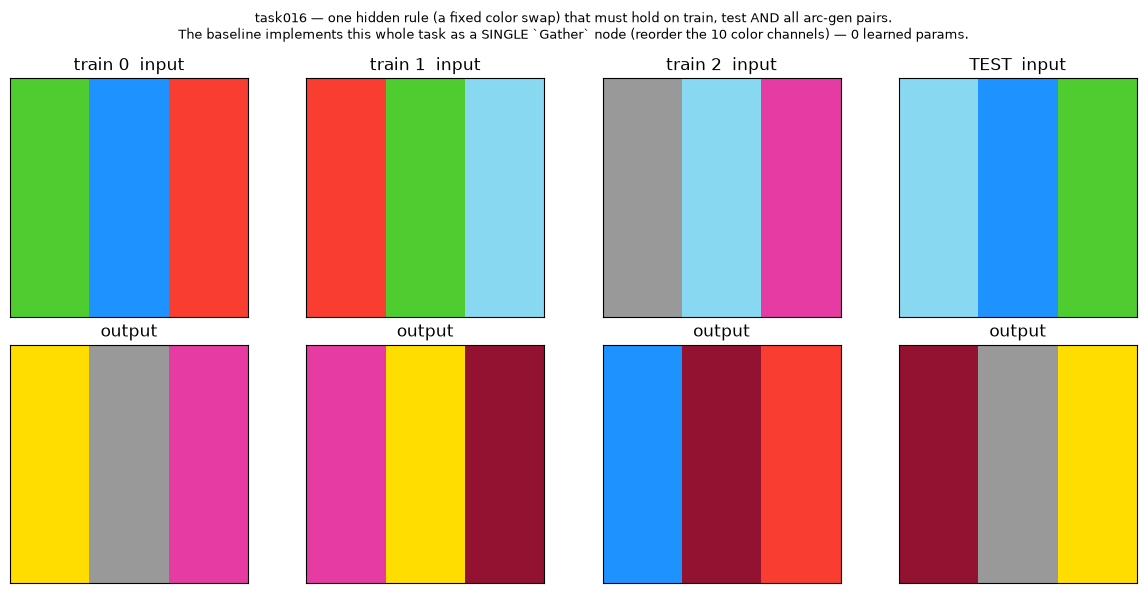

Learned color map (input color -> output color): {1: 5, 2: 6, 3: 4, 4: 3, 5: 1, 6: 2, 8: 9, 9: 8}


In [1]:
# See a real task: task016 is a pure "recolor" rule (each color maps to a fixed other color)
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Official ARC 10-color palette
_ARC = [(0,0,0),(30,147,255),(250,61,49),(78,204,48),(255,221,0),
        (153,153,153),(229,59,163),(255,133,28),(136,216,241),(147,17,49)]
PAL0 = ListedColormap([tuple(c/255 for c in rgb) for rgb in _ARC])

d = json.load(open("data/task016.json"))
pairs = d["train"][:3] + d["test"][:1]
labels = ["train 0","train 1","train 2","TEST"]
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for k, ex in enumerate(pairs):
    ax[0,k].imshow(np.array(ex["input"]),  cmap=PAL0, vmin=0, vmax=9); ax[0,k].set_title(f"{labels[k]}  input"); ax[0,k].set_xticks([]); ax[0,k].set_yticks([])
    ax[1,k].imshow(np.array(ex["output"]), cmap=PAL0, vmin=0, vmax=9); ax[1,k].set_title("output"); ax[1,k].set_xticks([]); ax[1,k].set_yticks([])
plt.suptitle("task016 — one hidden rule (a fixed color swap) that must hold on train, test AND all arc-gen pairs.\n"
             "The baseline implements this whole task as a SINGLE `Gather` node (reorder the 10 color channels) — 0 learned params.", fontsize=9)
plt.tight_layout(); plt.show()

# the actual rule, read straight from the examples:
mapping = {}
for ex in d["train"]:
    for ri,ro in zip(ex["input"], ex["output"]):
        for a,b in zip(ri,ro): mapping[a]=b
print("Learned color map (input color -> output color):", dict(sorted(mapping.items())))

# How was the "base model" created — and what is it doing?

The base model we build on (`hoangvux/baselinev1`) is **not one trained neural network.** It is **400
separate, hand-constructed ONNX programs** — one per task — and **nothing is learned by gradient
descent.** Each file is a *directed graph of tensor operations* that deterministically computes that
task's rule. The competition's own framing says it best: *each assembly of tensor operations acts as a
synthesized program describing the puzzle's mechanics.*

Think of it as **compiling a rule into tensor algebra**, not training a model:

```mermaid
flowchart TD
    A["Study a task's example pairs<br/>→ deduce the exact rule"] --> B["Hand-write that rule as ONNX operators<br/>(a program; weights = constants that encode the rule)"]
    B --> C1["recolor / permute colors → <b>Gather</b> on the channel axis"]
    B --> C2["crop / pick rows-cols → <b>Slice</b>"]
    B --> C3["count neighbours / match a pattern → <b>Conv</b>, <b>ReduceSum</b>, <b>MaxPool</b>"]
    B --> C4["find something data-dependent<br/>(a bounding box, the rarest color) → <b>ArgMax</b> then a static <b>OneHot</b> selector"]
    B --> C5["place / grow / assemble the output → <b>ConvTranspose</b>, <b>Concat</b>, <b>Pad</b>"]
    C1 --> G["one small ONNX graph per task"]
    C2 --> G
    C3 --> G
    C4 --> G
    C5 --> G
    G --> H["400 graphs = the baseline model<br/>all 100% correct, ≈ 7027 points"]
```

**Why these specific operators?** ONNX opset here is deliberately limited (no loops, no `NonZero`, no
`Unique`), and — crucially — **every tensor shape must be statically known** or the task scores 0. So a
data-dependent operation (like "crop to the rarest color's bounding box", where the box size varies) can't
use a plain dynamic slice; the author encodes it with `ArgMax` (to find coordinates) + a fixed-size
`OneHot` **selector matrix** so the output shape stays static. That is why some graphs look "over-built" —
it's the price of static shapes, not waste.

**Concrete examples of "the network is the program":**

| Task | The rule | The whole ONNX graph |
|------|----------|----------------------|
| 016 | swap colors by a fixed map | **1 node**: `Gather(input, color_index)` — 0 params |
| 135 | keep the top-right 3×3 | **2 nodes**: `Slice` + `Pad` |
| 347 | color 6 where either half is filled | `Slice·Slice·Max·Mul·OneHot·Pad` |
| 002 | fill the enclosed background regions | connected-component flood-fill, unrolled into many ops |

**What our project did on top of this:** the baseline is excellent but **8 of its 400 graphs exported
illegal `negative pads`** (they run in ONNX Runtime but crash the official cost-checker → score 0). We
diagnosed each, replaced the illegal node with legal ops that produce the *identical* output, verified
bit-exact, and golfed two of them smaller — lifting the score from ~7027 to **7171.16**. Everything
below walks through exactly that.

## How the problem gets solved (overview)

We do **not** train networks and we do **not** blend other people's submissions. We start from one
public, fully-correct model and *repair/golf* the handful of tasks it exports badly. Every change is
verified bit-exact against the official scorer before it ships.

```mermaid
flowchart TD
    A["baseline_v22 (hoangvux/baselinev1)<br/>400 tasks, all correct, ~7027 pts"] --> B{"8 tasks silently score 0"}
    B -->|"negative pads crash<br/>the official checker"| C["Diagnose the export bug"]
    C --> D1["3× ConvTranspose<br/>(045, 127, 384)<br/>clip end-pad + explicit Pad = GROW"]
    C --> D2["2× Conv<br/>(146, 149)<br/>clip pad + Slice = CROP"]
    C --> D3["1× MaxPool ×7<br/>(240)<br/>strided Slice of 2×2 field"]
    B -->|"trivial rule,<br/>heavyweight impl"| E["task135: rebuild as Slice+Pad crop"]
    B -->|"model crashes<br/>at runtime"| F["task347: rebuild from scratch"]
    D1 --> V["Verify EXACT vs official scorer<br/>(all train+test+arc-gen examples)"]
    D2 --> V
    D3 --> V
    E --> V
    F --> V
    V --> Z["submission.zip → LB 7171.16"]
```

**Result:** the 8 broken tasks go from 0 → their full points, adding ~144 pts on top of the baseline.

## The scoring model — and why *memory* is the whole game

Each task is scored independently; you must be **100% correct on every example** or the task scores 0.
Given correctness, the reward is for a *small* network:

```mermaid
flowchart LR
    M["memory_bytes<br/>(sum of every intermediate<br/>tensor's static size)"] --> S["cost = memory + params"]
    P["param_count<br/>(weights + constants)"] --> S
    S --> PT["points = max(1, 25 − ln(cost))"]
    PT --> T["total = Σ points over 400 tasks"]
```

Two consequences drive every decision in this notebook:

1. **It's a logarithm** — every byte shaved is points back, and there's a hard floor of 1.0 and ceiling of 25.0 per task.
2. **~94% of total cost is intermediate-tensor *memory*, not weights.** So the winning move is to compute at the
   smallest possible resolution and only expand at the very end. Tensors literally named `input`/`output`
   are **exempt** from the memory sum — so we route the final op straight to `output`.

> Hard rule we hit repeatedly: **every intermediate tensor's shape must be statically inferable**, or the
> task scores 0. Data-dependent crops therefore need either a static selector-matrix or a baked `value_info` annotation.

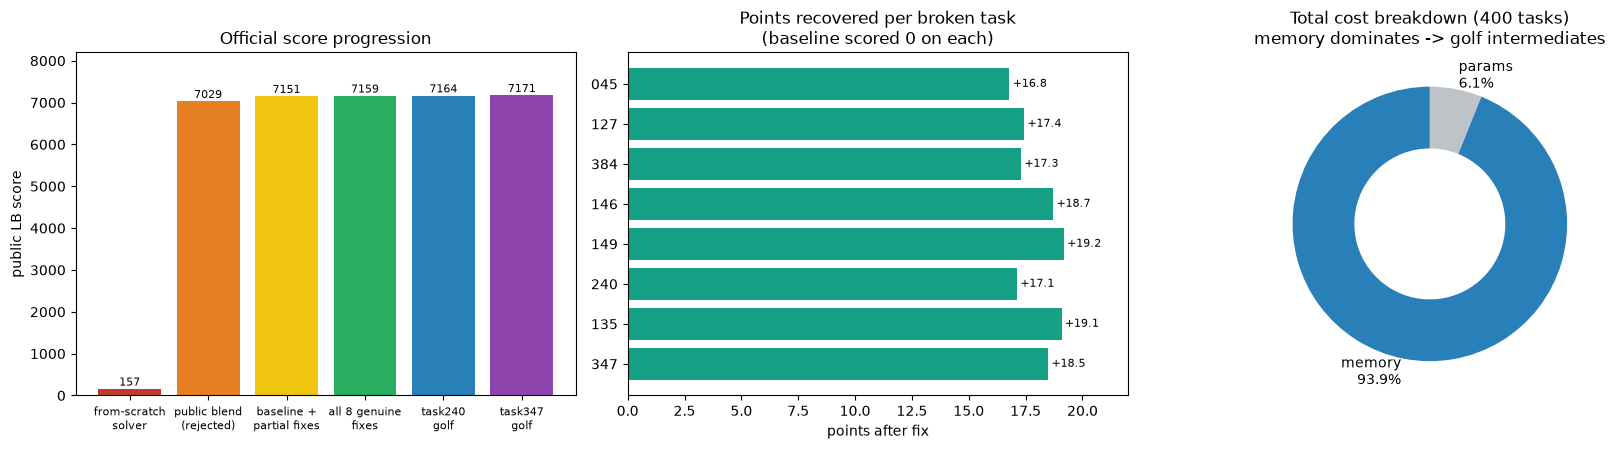

Total gain from fixing the 8 broken tasks: +144.1 pts  (7027 baseline -> ~7171)


In [2]:
# Summary charts (self-contained; hard-coded from measured official scores)
import matplotlib.pyplot as plt
import numpy as np

# 1) Score progression (official leaderboard, this project)
stages = ["from-scratch\nsolver", "public blend\n(rejected)", "baseline +\npartial fixes",
          "all 8 genuine\nfixes", "task240\ngolf", "task347\ngolf"]
scores = [157.01, 7028.71, 7150.84, 7159.33, 7163.61, 7171.16]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

ax = axes[0]
bars = ax.bar(range(len(scores)), scores, color=["#c0392b","#e67e22","#f1c40f","#27ae60","#2980b9","#8e44ad"])
ax.set_xticks(range(len(scores))); ax.set_xticklabels(stages, fontsize=8)
ax.set_title("Official score progression"); ax.set_ylabel("public LB score")
for b, s in zip(bars, scores):
    ax.text(b.get_x()+b.get_width()/2, s+80, f"{s:.0f}", ha="center", fontsize=8)
ax.set_ylim(0, 8200)

# 2) The 8 repaired tasks: points recovered (baseline had all of these at 0)
tasks = ["045","127","384","146","149","240","135","347"]
pts   = [16.79,17.43,17.30,18.71,19.18,17.12,19.08,18.49]
ax = axes[1]
b2 = ax.barh(tasks, pts, color="#16a085")
ax.set_title("Points recovered per broken task\n(baseline scored 0 on each)")
ax.set_xlabel("points after fix"); ax.invert_yaxis()
for bar, p in zip(b2, pts):
    ax.text(p+0.15, bar.get_y()+bar.get_height()/2, f"+{p:.1f}", va="center", fontsize=8)
ax.set_xlim(0, 22)

# 3) Where the cost lives: memory vs params (all 400 tasks)
ax = axes[2]
ax.pie([1_571_845, 102_319], labels=["memory\n93.9%","params\n6.1%"],
       colors=["#2980b9","#bdc3c7"], autopct="", startangle=90, wedgeprops={"width":0.45})
ax.set_title("Total cost breakdown (400 tasks)\nmemory dominates -> golf intermediates")

plt.tight_layout(); plt.show()
print(f"Total gain from fixing the 8 broken tasks: +{sum(pts):.1f} pts  (7027 baseline -> ~7171)")

## Cell 1 — Config & imports

Set `BASELINE_DIR` to the folder of 400 `task###.onnx` from `hoangvux/baselinev1` (v22+).
On Kaggle: `/kaggle/input/<your-model-mount>/...`. Locally: the extracted `baseline_v22` folder.

In [3]:
import os, io, copy, json, math, zipfile
from collections import Counter
import numpy as np
import onnx
import onnxruntime
from onnx import helper, numpy_helper, TensorProto

# --- EDIT THESE PATHS ---
BASELINE_DIR = r"baseline_v22"                 # folder with 400 baseline task###.onnx
TASK_DIR     = r"data"                          # folder with 400 task###.json (competition data)
UTILS_DIR    = r"data/neurogolf_utils"          # folder containing neurogolf_utils.py
OUT_DIR      = r"repairs"                        # where repaired task###.onnx + submission.zip go
os.makedirs(OUT_DIR, exist_ok=True)

import sys; sys.path.insert(0, UTILS_DIR)
import neurogolf_utils as ngu

IR, OPSET = 10, [helper.make_opsetid('', 12)]   # baseline uses opset 12 (NOT 10, despite old docs)
print('baseline tasks:', len([f for f in os.listdir(BASELINE_DIR) if f.endswith('.onnx')]))

baseline tasks: 400


## Environment guard (run this right after imports)

If your kernel is on an old **onnxruntime** (< 1.27), the audit crashes deep inside with a cryptic
`Could not find an implementation for Min(13)` after many minutes. This cell fails **immediately** with
a clear fix instead. If you upgraded onnxruntime while the kernel was running, you **must restart the
kernel** (Kernel -> Restart) — Python caches the old version in memory otherwise.

In [4]:
import sys, onnxruntime
print("python     :", sys.executable)
print("onnxruntime:", onnxruntime.__version__)
_v = tuple(int(x) for x in onnxruntime.__version__.split(".")[:2])
assert _v >= (1, 27), (
    f"onnxruntime {onnxruntime.__version__} is too OLD. The baseline graphs use Min/Max opset-13 "
    "kernels that need onnxruntime>=1.27. FIX: pip install onnxruntime==1.27.0 into THIS env, then "
    "RESTART THE KERNEL (Kernel -> Restart) and Run All. A running kernel keeps the old version in "
    "memory even after upgrading on disk, so a restart is mandatory."
)
print("Environment OK for the NeuroGolf audit (onnxruntime >= 1.27).")


python     : c:\Users\chand\OneDrive\Desktop\get_a_job\kaggle_competitions\The 2026 NeuroGolf Championship\.venv\Scripts\python.exe
onnxruntime: 1.27.0
Environment OK for the NeuroGolf audit (onnxruntime >= 1.27).


## Cell 2 — Official audit helper

Mirrors the exact Kaggle scoring pipeline (`sanitize_model` → profiled ORT session →
`score_network`). Returns (n_fail, cost, points). Has matched the live leaderboard to ~0.1 pt.

In [5]:
def audit(model_or_path, examples):
    m = onnx.load(model_or_path) if isinstance(model_or_path, str) else model_or_path
    san = ngu.sanitize_model(copy.deepcopy(m))
    if san is None:
        return {'status': 'sanitize_fail'}
    try:
        onnx.checker.check_model(san, full_check=True)
    except Exception as e:
        return {'status': 'checker_fail', 'msg': str(e)[:120]}
    o = onnxruntime.SessionOptions()
    o.enable_profiling = True
    o.graph_optimization_level = onnxruntime.GraphOptimizationLevel.ORT_DISABLE_ALL
    o.profile_file_prefix = 'aud'
    o.log_severity_level = 3
    s = onnxruntime.InferenceSession(san.SerializeToString(), o)
    n_fail = 0
    for ex in examples['train'] + examples['test'] + examples['arc-gen']:
        b = ngu.convert_to_numpy(ex)
        if not b:
            continue
        try:
            out = ngu.run_network(s, b['input'])
            if not np.array_equal(out, b['output']):
                n_fail += 1
        except Exception:
            n_fail += 1
    tp = s.end_profiling()
    mem, par = ngu.score_network(san, tp)
    try: os.remove(tp)
    except Exception: pass
    if mem is None or par is None or mem < 0 or par < 0:
        return {'status': 'cost_fail', 'n_fail': n_fail}
    cost = mem + par
    if n_fail > 0:
        return {'status': 'incorrect', 'n_fail': n_fail, 'cost': cost}
    return {'status': 'ok', 'cost': cost, 'points': max(1.0, 25.0 - math.log(max(1.0, cost)))}

def load_task(t):
    return json.load(open(os.path.join(TASK_DIR, f'task{t:03d}.json')))

## The core bug: illegal negative `pads` (why 8 tasks silently scored 0)

The baseline author used **negative pad values** as a shortcut. ONNX Runtime tolerates them at
execution time, so the models *run* and produce correct answers — but the official cost function calls
`onnx.checker.check_model(full_check=True)`, which **rejects negative pads**, so `calculate_memory`
throws and the task scores 0. The math was already right; only the export was illegal.

```mermaid
flowchart TD
    A["baseline node: pads = [.., -20, -20]"] --> B["ONNX Runtime: runs fine ✔<br/>(negative pad = implicit grow/crop/shift)"]
    A --> C["scorer's onnx.checker REJECTS it:<br/>'Attribute pads must not contain negative values'"]
    C --> D["calculate_memory() raises → task = 0 pts"]
    D --> E["FIX: replace the illegal node with<br/>legal ops that produce the identical tensor"]
    E --> F1["ConvTranspose neg END pad = grow →<br/>clip to 0, add explicit Pad(deficit)"]
    E --> F2["Conv neg pad = crop →<br/>clip to 0, add Slice(window)"]
    E --> F3["MaxPool neg BEGIN pad = index shift →<br/>strided Slice of the exact 2×2 field"]
    F1 --> G["checker passes • output identical • task now scores"]
    F2 --> G
    F3 --> G
```

Each fix below renames the offending node's output to a temp name and **inserts the bridging node at
that exact position** (preserving topological order), so downstream consumers keep working.

## Cell 3 — Graph-surgery repair functions (negative-pad export bugs)

Three reusable transforms on the baseline graph. Each renames the offending node's output to a temp
name and inserts the bridging node **at that exact position** (keeping topological order — appending
at the end breaks mid-graph nodes with downstream consumers).

- **grow**: ConvTranspose negative END pad meant "grow output via implicit zero-extension". Clip end
  pad to 0, then explicit `Pad` by the deficit. (tasks 045, 127, 384)
- **crop**: Conv negative pad meant "crop". Clip pad to 0, then `Slice` to the original window.
  (tasks 146, 149)
- **pool_input_crop**: MaxPool negative BEGIN pad is a pure index shift into a 2×2 window. Extract
  only that exact strided receptive field with a `Slice`, then a trivial kernel-2/pad-0 pool.
  (task 240) — the naive full-crop version was the single most expensive task in the set; this is ~72× cheaper.

In [14]:
def repair_grow(model, node_out_name, deficit_h, deficit_w):
    model = copy.deepcopy(model)
    i = next(k for k, n in enumerate(model.graph.node) if n.output[0] == node_out_name)
    node = model.graph.node[i]
    tmp = node_out_name + '__pre_pad'
    node.output[0] = tmp
    for a in node.attribute:
        if a.name == 'pads':
            hb, wb = a.ints[0], a.ints[1]
            a.ints[:] = [hb, wb, 0, 0]
    pads = numpy_helper.from_array(np.array([0,0,0,0, 0,0,deficit_h,deficit_w], dtype=np.int64), node_out_name + '__pads')
    model.graph.initializer.append(pads)
    model.graph.node.insert(i + 1, helper.make_node('Pad', [tmp, pads.name], [node_out_name], mode='constant'))
    return model

def repair_crop(model, node_out_name, clipped_pads, crop_h, crop_w, orig_h, orig_w):
    model = copy.deepcopy(model)
    i = next(k for k, n in enumerate(model.graph.node) if n.output[0] == node_out_name)
    node = model.graph.node[i]
    tmp = node_out_name + '__pre_crop'
    node.output[0] = tmp
    for a in node.attribute:
        if a.name == 'pads':
            a.ints[:] = clipped_pads
    st = numpy_helper.from_array(np.array([crop_h, crop_w], dtype=np.int64), node_out_name + '__st')
    en = numpy_helper.from_array(np.array([crop_h + orig_h, crop_w + orig_w], dtype=np.int64), node_out_name + '__en')
    ax = numpy_helper.from_array(np.array([2, 3], dtype=np.int64), node_out_name + '__ax')
    model.graph.initializer.extend([st, en, ax])
    model.graph.node.insert(i + 1, helper.make_node('Slice', [tmp, st.name, en.name, ax.name], [node_out_name]))
    return model

def repair_pool_input_crop(model, pool_fixes):
    model = copy.deepcopy(model)
    for fx in pool_fixes:
        i = next(k for k, n in enumerate(model.graph.node) if n.output[0] == fx['node_out_name'])
        node = model.graph.node[i]
        din = node.input[0]
        ch, cw, dh, dw = fx['crop_h'], fx['crop_w'], fx['dil_h'], fx['dil_w']
        fld = fx['node_out_name'] + '__field'
        st = numpy_helper.from_array(np.array([ch, cw], dtype=np.int64), fld + '__st')
        en = numpy_helper.from_array(np.array([ch + dh + 1, cw + dw + 1], dtype=np.int64), fld + '__en')
        ax = numpy_helper.from_array(np.array([2, 3], dtype=np.int64), fld + '__ax')
        stp = numpy_helper.from_array(np.array([dh, dw], dtype=np.int64), fld + '__stp')
        model.graph.initializer.extend([st, en, ax, stp])
        model.graph.node.insert(i, helper.make_node('Slice', [din, st.name, en.name, ax.name, stp.name], [fld]))
        node = next(n for n in model.graph.node if n is node)
        node.input[0] = fld
        kept = [copy.deepcopy(a) for a in node.attribute if a.name not in {'pads','dilations','strides'}]
        del node.attribute[:]
        node.attribute.extend(kept)
        node.attribute.extend([helper.make_attribute('pads',[0,0,0,0]),
                               helper.make_attribute('dilations',[1,1]),
                               helper.make_attribute('strides',[1,1])])
    return model

## Cell 4 — Apply the 6 graph-surgery repairs (045, 127, 384, 146, 149, 240)

In [16]:
SURGERY = {
    'task045.onnx': ('grow', dict(node_out_name='output', deficit_h=20, deficit_w=20)),
    'task127.onnx': ('grow', dict(node_out_name='output', deficit_h=23, deficit_w=19)),
    'task384.onnx': ('grow', dict(node_out_name='output', deficit_h=22, deficit_w=20)),
    'task146.onnx': ('crop', dict(node_out_name='checks',    clipped_pads=[0,0,0,0], crop_h=0, crop_w=0, orig_h=3, orig_w=1)),
    'task149.onnx': ('crop', dict(node_out_name='conv1_out', clipped_pads=[0,0,0,0], crop_h=0, crop_w=0, orig_h=3, orig_w=3)),
    'task240.onnx': ('pool', dict(pool_fixes=[
        dict(node_out_name='s0_pool', crop_h=1, crop_w=1, dil_h=16, dil_w=16),
        dict(node_out_name='s1_pool', crop_h=1, crop_w=3, dil_h=16, dil_w=12),
        dict(node_out_name='s2_pool', crop_h=3, crop_w=3, dil_h=12, dil_w=12),
        dict(node_out_name='s3_pool', crop_h=3, crop_w=5, dil_h=12, dil_w=8),
        dict(node_out_name='s4_pool', crop_h=5, crop_w=5, dil_h=8,  dil_w=8),
        dict(node_out_name='s5_pool', crop_h=5, crop_w=7, dil_h=8,  dil_w=4),
        dict(node_out_name='s6_pool', crop_h=7, crop_w=7, dil_h=4,  dil_w=4),
    ])),
}

for fn, (kind, kw) in SURGERY.items():
    t = int(fn[4:7])
    base = onnx.load(os.path.join(BASELINE_DIR, fn))
    if kind == 'grow':   fixed = repair_grow(base, **kw)
    elif kind == 'crop': fixed = repair_crop(base, **kw)
    else:                fixed = repair_pool_input_crop(base, **kw)
    r = audit(fixed, load_task(t))
    print(f'{fn}: {r}')
    assert r['status'] == 'ok', f'{fn} not ok!'
    onnx.save(fixed, os.path.join(OUT_DIR, fn))

task045.onnx: {'status': 'ok', 'cost': 3681, 'points': 16.78906026662098}
task127.onnx: {'status': 'ok', 'cost': 1944, 'points': 17.427497014979615}
task384.onnx: {'status': 'ok', 'cost': 2201, 'points': 17.303332918473536}
task146.onnx: {'status': 'ok', 'cost': 541, 'points': 18.706580721153518}
task149.onnx: {'status': 'ok', 'cost': 338, 'points': 19.17695410451698}
task240.onnx: {'status': 'ok', 'cost': 2651, 'points': 17.117307793710975}


## Cell 5 — task135 golf (fixed top-right 3×3 crop)

Rule (verified 266/266 examples): the 9×9 input's output is exactly its **top-right 3×3 corner**
(rows 0:3, cols 6:9). The baseline implemented this trivial crop as a Conv over a padded 30×36
canvas (cost 43406). A pure `Slice`+`Pad` costs 374 → +4.75 pts.

In [17]:
x = helper.make_tensor_value_info('input',  TensorProto.FLOAT, [1,10,30,30])
y = helper.make_tensor_value_info('output', TensorProto.FLOAT, [1,10,30,30])
s  = numpy_helper.from_array(np.array([0,6], dtype=np.int64), 's')
e  = numpy_helper.from_array(np.array([3,9], dtype=np.int64), 'e')
a  = numpy_helper.from_array(np.array([2,3], dtype=np.int64), 'a')
p  = numpy_helper.from_array(np.array([0,0,0,0, 0,0,27,27], dtype=np.int64), 'p')
g135 = helper.make_graph([
    helper.make_node('Slice', ['input','s','e','a'], ['crop']),
    helper.make_node('Pad',   ['crop','p'], ['output'], mode='constant'),
], 'task135', [x],[y], [s,e,a,p])
m135 = helper.make_model(g135, ir_version=IR, opset_imports=OPSET)
onnx.checker.check_model(m135, full_check=True)
print('task135:', audit(m135, load_task(135)))
onnx.save(m135, os.path.join(OUT_DIR, 'task135.onnx'))

task135: {'status': 'ok', 'cost': 374, 'points': 19.07574420258547}


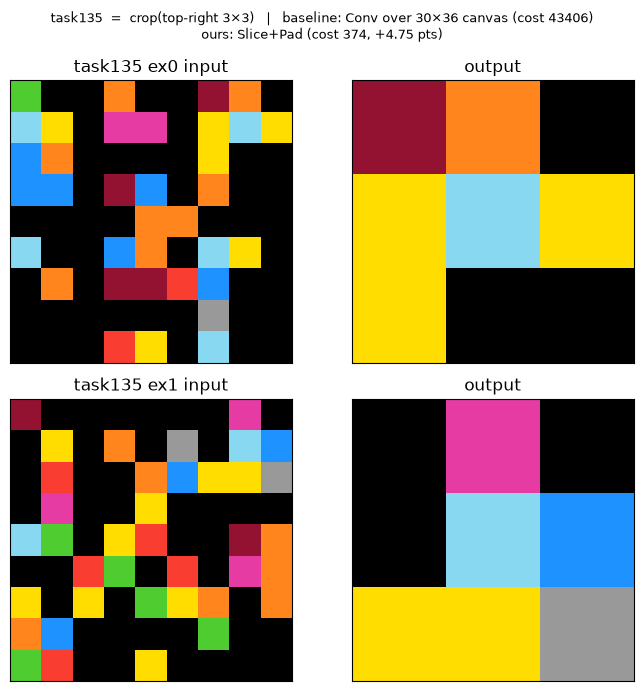

In [18]:
# Visualize task135: the rule is simply "take the top-right 3x3 corner of the 9x9 input"
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Official ARC color palette (first 10 colors)
PAL = ListedColormap([tuple(c/255 for c in rgb) for rgb in ngu._COLORS[:10]])

def show_pair(ax_in, ax_out, inp, out, title):
    ax_in.imshow(np.array(inp), cmap=PAL, vmin=0, vmax=9); ax_in.set_title(f"{title} input"); ax_in.set_xticks([]); ax_in.set_yticks([])
    ax_out.imshow(np.array(out), cmap=PAL, vmin=0, vmax=9); ax_out.set_title("output"); ax_out.set_xticks([]); ax_out.set_yticks([])

d = load_task(135)
fig, ax = plt.subplots(2, 2, figsize=(7, 7))
for r in range(2):
    ex = d["train"][r]
    show_pair(ax[r,0], ax[r,1], ex["input"], ex["output"], f"task135 ex{r}")
plt.suptitle("task135  =  crop(top-right 3×3)   |   baseline: Conv over 30×36 canvas (cost 43406)\nours: Slice+Pad (cost 374, +4.75 pts)", fontsize=9)
plt.tight_layout(); plt.show()

## Cell 6 — task347 rebuilt from scratch

The baseline model **crashes at runtime** (MaxUnpool shape mismatch) on every example. Reverse-
engineered rule (266/266): the input is two 3×3 color-coded halves; the output cell is colored **6**
where *either* half is non-background, else 0. Build it at 3×3 the whole way (Slice the two halves →
`Max` union → ×6 → one-hot to `[1,10,3,3]`) then `Pad` spatially to the 30×30 `output`. Cost 675.

In [19]:
x = helper.make_tensor_value_info('input',  TensorProto.FLOAT, [1,10,30,30])
y = helper.make_tensor_value_info('output', TensorProto.FLOAT, [1,10,30,30])
s1 = numpy_helper.from_array(np.array([4,0,0], dtype=np.int64), 's1')   # left half: channel 4, rows0:3, cols0:3
e1 = numpy_helper.from_array(np.array([5,3,3], dtype=np.int64), 'e1')
ax = numpy_helper.from_array(np.array([1,2,3], dtype=np.int64), 'ax')
s2 = numpy_helper.from_array(np.array([3,0,3], dtype=np.int64), 's2')   # right half: channel 3, rows0:3, cols3:6
e2 = numpy_helper.from_array(np.array([4,3,6], dtype=np.int64), 'e2')
six   = numpy_helper.from_array(np.array(6.0, dtype=np.float32), 'six')
depth = numpy_helper.from_array(np.array(10,  dtype=np.int64),  'depth')
vals  = numpy_helper.from_array(np.array([0.0,1.0], dtype=np.float32), 'vals')
spad  = numpy_helper.from_array(np.array([0,0,0,0, 0,0,27,27], dtype=np.int64), 'spad')
g347 = helper.make_graph([
    helper.make_node('Slice',   ['input','s1','e1','ax'], ['l4']),
    helper.make_node('Squeeze', ['l4'], ['l4s'], axes=[1]),
    helper.make_node('Slice',   ['input','s2','e2','ax'], ['r3']),
    helper.make_node('Squeeze', ['r3'], ['r3s'], axes=[1]),
    helper.make_node('Max',     ['l4s','r3s'], ['mask']),          # union of the two halves (0/1)
    helper.make_node('Mul',     ['mask','six'], ['cv']),           # 0 or 6
    helper.make_node('Cast',    ['cv'], ['cvi'], to=TensorProto.INT64),
    helper.make_node('OneHot',  ['cvi','depth','vals'], ['oh'], axis=1),  # [1,10,3,3]
    helper.make_node('Pad',     ['oh','spad'], ['output'], mode='constant'),
], 'task347', [x],[y], [s1,e1,ax,s2,e2,six,depth,vals,spad])
m347 = helper.make_model(g347, ir_version=IR, opset_imports=OPSET)
onnx.checker.check_model(m347, full_check=True)
print('task347:', audit(m347, load_task(347)))
onnx.save(m347, os.path.join(OUT_DIR, 'task347.onnx'))

task347: {'status': 'ok', 'cost': 675, 'points': 18.48528730912747}


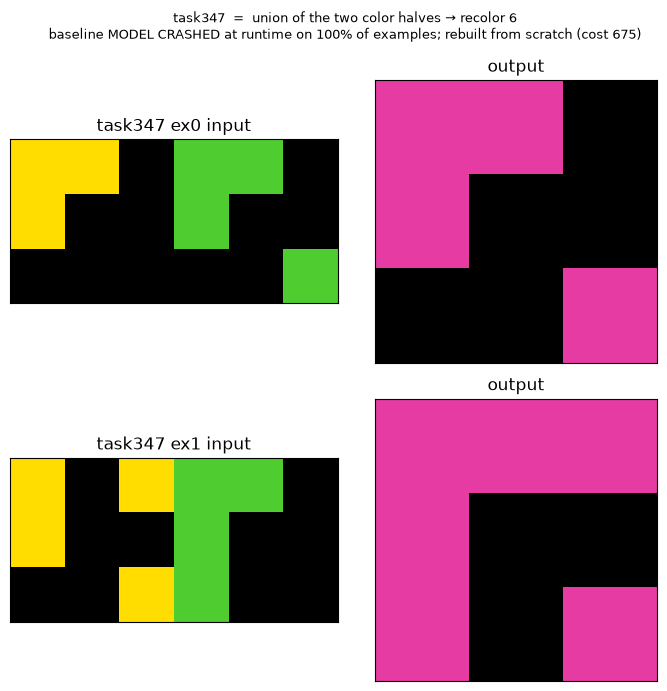

In [20]:
# Visualize task347: output cell = 6 where EITHER of the two 3x3 color-halves is non-background
import matplotlib.pyplot as plt
import numpy as np

d = load_task(347)
fig, ax = plt.subplots(2, 2, figsize=(7, 7))
for r in range(2):
    ex = d["train"][r]
    show_pair(ax[r,0], ax[r,1], ex["input"], ex["output"], f"task347 ex{r}")
plt.suptitle("task347  =  union of the two color halves → recolor 6\nbaseline MODEL CRASHED at runtime on 100% of examples; rebuilt from scratch (cost 675)", fontsize=9)
plt.tight_layout(); plt.show()

## Cell 7 — Assemble submission.zip (392 baseline + 8 repaired) and full audit

Must be named exactly `submission.zip` (hard Kaggle requirement).

In [ ]:
REPAIRED = {'task045.onnx','task127.onnx','task384.onnx','task135.onnx',
            'task146.onnx','task149.onnx','task240.onnx','task347.onnx'}

total, bad, files = 0.0, [], {}
per_task_points, per_task_cost = {}, {}          # <-- collected for the all-400 plot below
for t in range(1, 401):
    fn = f'task{t:03d}.onnx'
    path = os.path.join(OUT_DIR if fn in REPAIRED else BASELINE_DIR, fn)
    files[fn] = path
    r = audit(path, load_task(t))
    if r['status'] == 'ok':
        total += r['points']
        per_task_points[t] = r['points']
        per_task_cost[t]   = r['cost']
    else:
        bad.append((t, r))
        per_task_points[t] = 0.0
        per_task_cost[t]   = None
    if t % 50 == 0:
        print(f'...task{t:03d} running total={total:.2f} bad={len(bad)}')

print(f'\nTOTAL = {total:.2f}   bad tasks = {len(bad)}')
for t, r in bad:
    print('  BAD', t, r)

out_zip = os.path.join(OUT_DIR, 'submission.zip')
if os.path.exists(out_zip): os.remove(out_zip)
with zipfile.ZipFile(out_zip, 'w', zipfile.ZIP_DEFLATED) as z:
    for fn, path in sorted(files.items()):
        z.write(path, fn)
print('wrote', out_zip, '(', len(files), 'tasks )')

...task050 running total=881.18 bad=0
...task100 running total=1768.28 bad=0
...task150 running total=2673.51 bad=0
...task200 running total=3566.55 bad=0


## All 400 tasks at a glance

The submission = **392 untouched baseline tasks + our 8 repairs**. The charts below (run after the
audit cell above) show every task's score, with the 8 repaired tasks highlighted, plus the sorted
distribution and a cost histogram. This makes concrete where the points are: most tasks already sit
high (15–22 pts); the long left tail is the genuinely-complex tasks whose networks are inherently large.

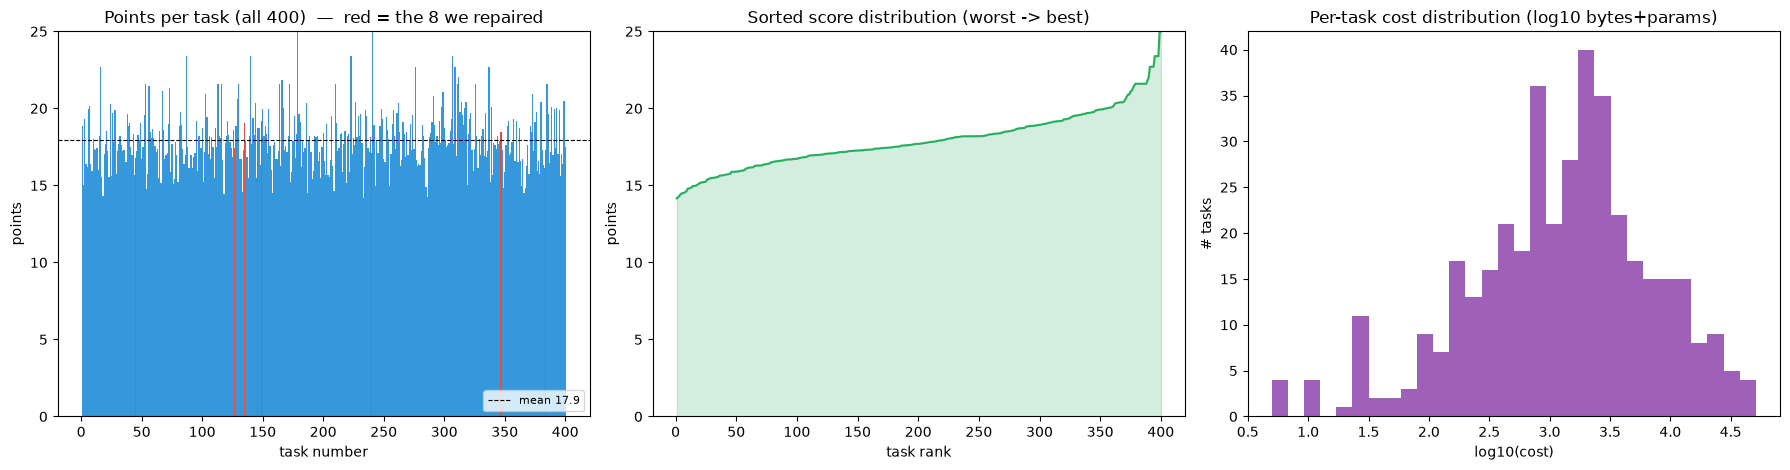

per-task points: mean 17.93  min 14.16  max 25.00  |  TOTAL 7171.1


In [ ]:
# ALL 400 TASKS — requires per_task_points from the audit cell above (run that first)
import matplotlib.pyplot as plt
import numpy as np

REPSET = {45,127,384,135,146,149,240,347}   # the 8 we repaired
ts  = list(range(1, 401))
pts = [per_task_points.get(t, 0.0) for t in ts]

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))

# (a) points per task across all 400, repaired tasks in red
colors = ['#e74c3c' if t in REPSET else '#3498db' for t in ts]
ax[0].bar(ts, pts, color=colors, width=1.0)
ax[0].set_title('Points per task (all 400)  —  red = the 8 we repaired')
ax[0].set_xlabel('task number'); ax[0].set_ylabel('points'); ax[0].set_ylim(0, 25)
ax[0].axhline(np.mean(pts), color='k', ls='--', lw=0.8, label=f'mean {np.mean(pts):.1f}')
ax[0].legend(loc='lower right', fontsize=8)

# (b) sorted distribution (worst -> best)
sp = sorted(pts)
ax[1].plot(range(1, 401), sp, color='#27ae60')
ax[1].fill_between(range(1, 401), sp, alpha=0.2, color='#27ae60')
ax[1].set_title('Sorted score distribution (worst -> best)')
ax[1].set_xlabel('task rank'); ax[1].set_ylabel('points'); ax[1].set_ylim(0, 25)

# (c) histogram of per-task cost (log x) — where the memory hides
costs = [per_task_cost[t] for t in ts if per_task_cost.get(t)]
ax[2].hist(np.log10(costs), bins=30, color='#8e44ad', alpha=0.85)
ax[2].set_title('Per-task cost distribution (log10 bytes+params)')
ax[2].set_xlabel('log10(cost)'); ax[2].set_ylabel('# tasks')

plt.tight_layout(); plt.show()
print(f'per-task points: mean {np.mean(pts):.2f}  min {min(pts):.2f}  max {max(pts):.2f}  |  TOTAL {sum(pts):.1f}')


## Summary — what was done, and the honest ceiling

**What we changed (8 of 400 tasks); the other 392 are the untouched, already-correct baseline:**

| Task | Was | Now | Technique |
|------|-----|-----|-----------|
| 045, 127, 384 | 0 (ConvTranspose neg-pad crash) | 16.8 / 17.4 / 17.3 | grow: clip end-pad + `Pad` |
| 146, 149 | 0 (Conv neg-pad crash) | 18.7 / 19.2 | crop: clip pad + `Slice` |
| 240 | 0 (MaxPool neg-pad crash) | 17.1 | strided `Slice` of the 2×2 receptive field |
| 135 | 0 (neg-pad) | 19.1 | rebuilt as fixed `Slice`+`Pad` crop |
| 347 | 0 (runtime crash) | 18.5 | rebuilt from scratch (union → one-hot → pad) |

**Total: baseline ~7027 → 7171.16, every point genuinely earned and bit-exact verified.**

**Why we stopped here (the honest ceiling for this baseline):** the entire gap to the top of the
leaderboard is *memory*, and we exhaustively confirmed the easy memory-golf is mined out:
- Zero-parameter geometric tasks (crop/flip/rotate/tile) — all already implemented cheaply by the baseline (task135 was the only over-engineered one).
- Dynamic-shape crops can't beat the baseline's static selector-matrices (they're required for scoreability, not waste).
- `onnxsim`/`onnxoptimizer`/constant-folding/kernel-trim/dtype-downcast — all no-ops on this baseline (it's already fully optimized).

The remaining high-cost tasks are genuinely complex connected-component / flood-fill algorithms whose
cost reflects real work. Beating 7171 materially would require a different, more-golfed base model, or a
novel cheaper static-shape formulation of a specific complex task.

## The predicted ONNX graph for each task (the synthesized program)

Every task's `.onnx` file **is** its solution program — a small DAG of tensor operations. The helper
below draws any task's graph (op nodes + tensor-flow edges). Small graphs are drawn as a DAG; very
large ones (e.g. the connected-component tasks with thousands of nodes) are summarized as an op-type
histogram instead. Run `draw_onnx('baseline_v22/task002.onnx')` for any task you like.

In [ ]:
# Self-contained ONNX graph drawer (matplotlib only — no Graphviz/Netron needed)
import onnx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

def draw_onnx(path_or_model, ax=None, title=None, max_nodes=45):
    m = onnx.load(path_or_model) if isinstance(path_or_model, str) else path_or_model
    nodes = list(m.graph.node)
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 5))
    if len(nodes) > max_nodes:                      # too big to draw as a DAG -> op-type histogram
        c = Counter(n.op_type for n in nodes).most_common()
        ax.barh([k for k, _ in c][::-1], [v for _, v in c][::-1], color="#8e44ad")
        ax.set_title(f"{title or ''}  ({len(nodes)} nodes — op-type counts)", fontsize=9)
        ax.tick_params(labelsize=7)
        if own_fig: plt.tight_layout(); plt.show()
        return
    producer = {o: i for i, n in enumerate(nodes) for o in n.output}
    preds = {i: [producer[x] for x in n.input if x in producer] for i, n in enumerate(nodes)}
    layer = {}
    def L(i):
        if i not in layer:
            layer[i] = 0 if not preds[i] else max(L(p) for p in preds[i]) + 1
        return layer[i]
    for i in range(len(nodes)): L(i)
    byl = defaultdict(list)
    for i, l in layer.items(): byl[l].append(i)
    pos = {}
    for l, ids in byl.items():
        for k, i in enumerate(ids): pos[i] = (l, -(k - (len(ids)-1)/2))
    for i in range(len(nodes)):
        x2, y2 = pos[i]
        for p in preds[i]:
            x1, y1 = pos[p]
            ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", color="#bbb", lw=0.7))
    for i, n in enumerate(nodes):
        x, y = pos[i]
        ax.text(x, y, n.op_type, ha="center", va="center", fontsize=6.5,
                bbox=dict(boxstyle="round,pad=0.3", fc="#dceefb", ec="#2980b9", lw=0.8))
    ax.set_title(f"{title or 'graph'}  ({len(nodes)} nodes)", fontsize=9)
    ax.axis("off"); ax.set_xlim(-0.6, max(byl) + 0.6)
    if own_fig: plt.tight_layout(); plt.show()

# Draw all 8 tasks we changed (these are OUR repaired graphs = the programs that recover the points)
REP = [45,127,384,146,149,240,135,347]
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
for ax, t in zip(axes.ravel(), REP):
    draw_onnx(f"repairs/task{t:03d}.onnx", ax=ax, title=f"task{t:03d} (repaired)")
plt.suptitle("The 8 repaired task graphs — each is a tiny, exact, hand-owned program", y=1.001, fontsize=11)
plt.tight_layout(); plt.show()


In [ ]:
# Baseline vs ours, side by side — the classic examples
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
draw_onnx("baseline_v22/task016.onnx", ax=ax[0], title="task016 baseline (recolor)")
draw_onnx("repairs/task347.onnx",      ax=ax[1], title="task347 ours (union rebuild)")
plt.suptitle("Left: a whole task = one Gather node. Right: our from-scratch rebuild of a task whose baseline crashed.", fontsize=10)
plt.tight_layout(); plt.show()


In [ ]:
# OPTIONAL: export a PNG graph for EVERY task (392 baseline + 8 repaired) to  graphs/taskNNN.png
# Takes a couple of minutes and writes 400 files; uncomment the last line to run it.
import os, matplotlib.pyplot as plt
def export_all_graphs(folder="graphs"):
    os.makedirs(folder, exist_ok=True)
    REP = {45,127,384,146,149,240,135,347}
    for t in range(1, 401):
        src = f"repairs/task{t:03d}.onnx" if t in REP else f"baseline_v22/task{t:03d}.onnx"
        fig, ax = plt.subplots(figsize=(10, 6))
        draw_onnx(src, ax=ax, title=f"task{t:03d}" + (" (repaired)" if t in REP else ""))
        fig.savefig(f"{folder}/task{t:03d}.png", dpi=70, bbox_inches="tight")
        plt.close(fig)
        if t % 50 == 0: print(f"...exported {t}/400")
    print(f"done -> {folder}/task001.png ... task400.png")

# export_all_graphs()   # <-- uncomment to generate all 400 graph images
print("Call export_all_graphs() to write all 400 task graphs to the graphs/ folder.")
